In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('raw_data/StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [8]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# **Gender boxplots (math vs reading)**

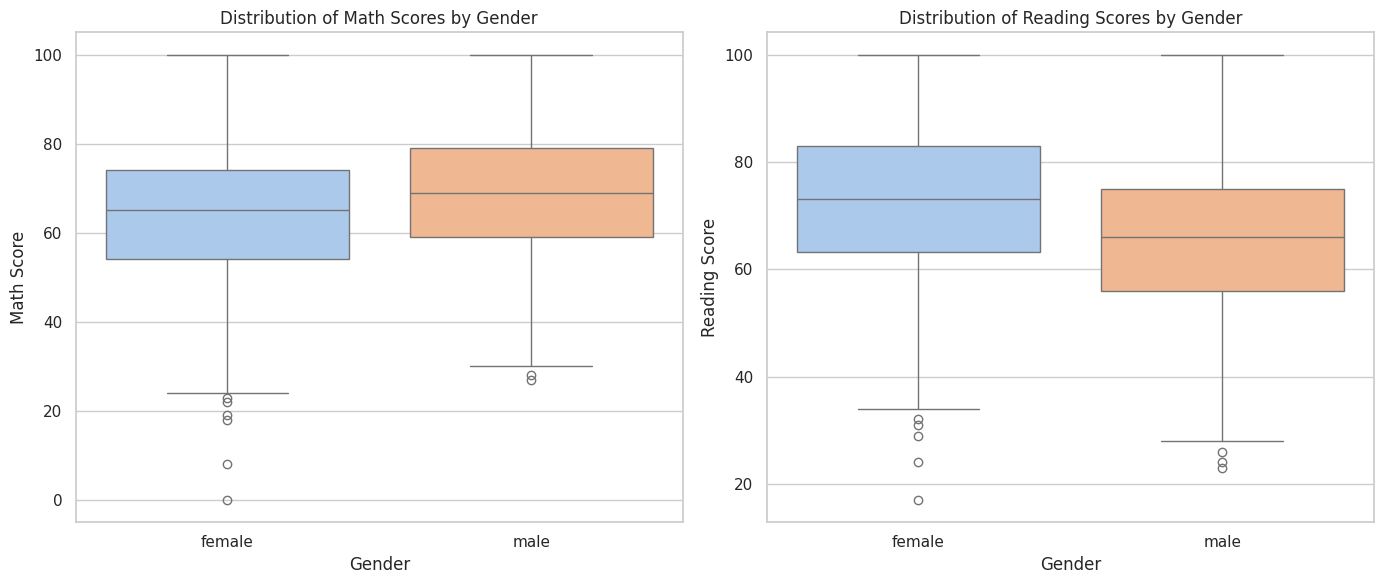

In [12]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Math Score by Gender
sns.boxplot(x='gender', y='math score', hue='gender', data=df, ax=axes[0], palette='pastel', legend=False)
axes[0].set_title('Distribution of Math Scores by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Math Score')

# reading Score by Gender
sns.boxplot(x='gender', y='reading score', hue='gender', data=df, ax=axes[1], palette='pastel', legend=False)
axes[1].set_title('Distribution of Reading Scores by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Reading Score')

plt.tight_layout()
plt.show()

Based on the boxplots, there are clear gender differences in performance across the two subject:


*   Math Scores: The median score for males is higher than for females. The male distribution (interquartile range) is also shifted slightly upward compared to the female distribution.
*   Reading Scores: The trend reverses here. Females have a notably higher median reading score and their entire distribution is shifted significantly higher than that of the males.

tldr: In this dataset, males tend to perform better in math, while females tend to perform better in reading.


# **Test prep impact on math**

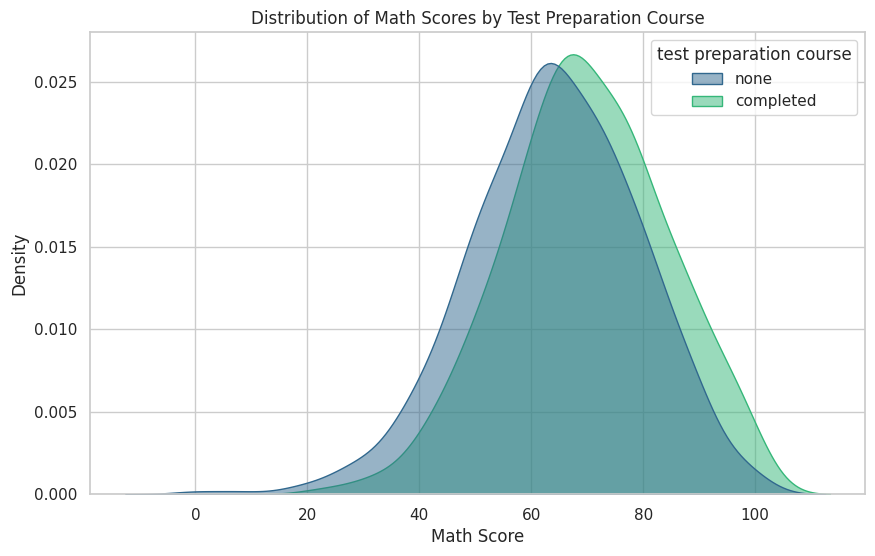

In [14]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='math score', hue='test preparation course', fill=True, common_norm=False, palette='viridis', alpha=0.5)
plt.title('Distribution of Math Scores by Test Preparation Course')
plt.xlabel('Math Score')
plt.ylabel('Density')
plt.show()

The plot illustrates the distribution of math scores for both groups:

*   Higher Density at High Scores: The distribution for students who completed the test preparation course (green) is shifted to the right compared to those who took none (blue).

*   Peak Comparison: The peak (mode) for the 'completed' group is at a higher math score than the 'none' group.
Overlap: While there is significant overlap, the 'none' group has a thicker tail on the lower end of the score spectrum, indicating more students in that group scored lower.

*   Overlap: While there is significant overlap, the 'none' group has a thicker tail on the lower end of the score spectrum, indicating more students in that group scored lower.


tldr: Overall, students who completed the preparation course tend to have higher math scores


# **Lunch type and average performance**

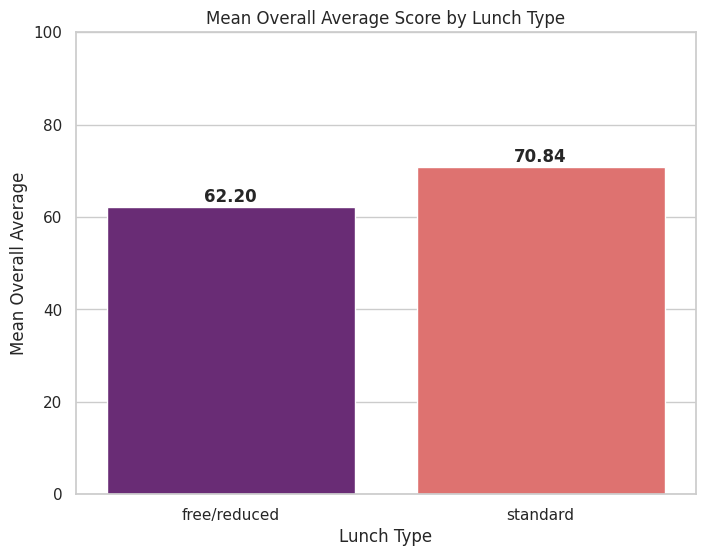

In [15]:
# Calculate the overall average score for each student
df['overall_avg'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)

# Group by lunch type and calculate the mean of the overall average
lunch_stats = df.groupby('lunch')['overall_avg'].mean().reset_index()

# Create the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x='lunch', y='overall_avg', hue='lunch', data=lunch_stats, palette='magma', legend=False)

plt.title('Mean Overall Average Score by Lunch Type')
plt.xlabel('Lunch Type')
plt.ylabel('Mean Overall Average')
plt.ylim(0, 100)

for i, val in enumerate(lunch_stats['overall_avg']):
    plt.text(i, val + 1, f'{val:.2f}', ha='center', fontweight='bold')

plt.show()

**Performance Gap:** Students who receive standard lunch significantly outperform those on free/reduced lunch. Specifically, the mean overall average score for the standard lunch group is 70.84, compared to 62.20 for the free/reduced group.

**Socio-economic Indicator**: Lunch type often serves as a proxy for socio-economic status. These results suggest that students from higher socio-economic backgrounds (standard lunch) tend to have better academic outcomes across math, reading, and writing.

# **Subject correlations**

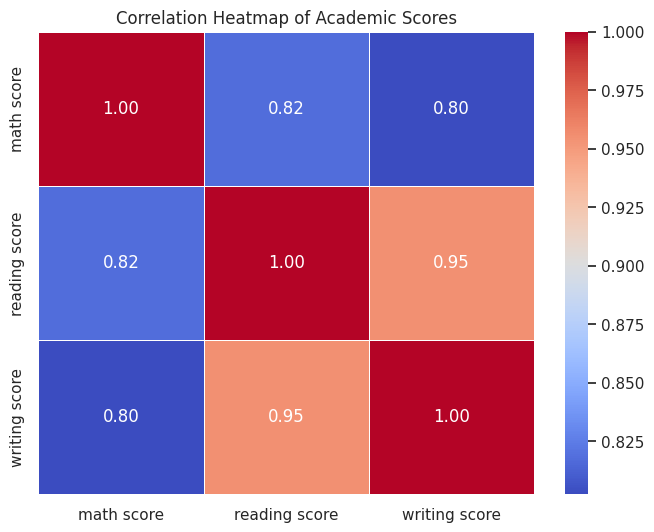

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for the score columns
corr_matrix = df[['math score', 'reading score', 'writing score']].corr()

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Academic Scores')
plt.show()

The heatmap shows that the three subjects move together very strongly. Reading and writing have a nearly perfect correlation of 0.95, while math also shows a strong positive relationship with both reading (0.82) and writing (0.80), indicating that students who do well in one subject are very likely to do well in the others.

# **Math vs reading with trend lines by test prep**

<Figure size 1000x700 with 0 Axes>

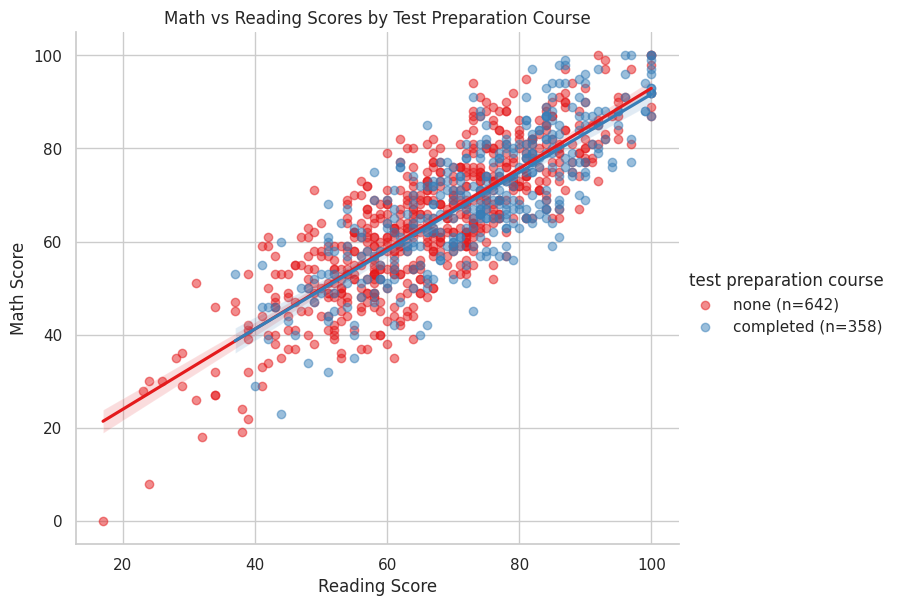

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count samples for the legend labels
counts = df['test preparation course'].value_counts()
label_none = f"none (n={counts['none']})"
label_completed = f"completed (n={counts['completed']})"

# Map the labels for the plot
plot_df = df.copy()
plot_df['test preparation course'] = plot_df['test preparation course'].map({'none': label_none, 'completed': label_completed})

# Create the scatter plot with linear regression lines
plt.figure(figsize=(10, 7))
sns.lmplot(data=plot_df, x='reading score', y='math score', hue='test preparation course',
           palette='Set1', scatter_kws={'alpha':0.5}, height=6, aspect=1.2)

plt.title('Math vs Reading Scores by Test Preparation Course')
plt.xlabel('Reading Score')
plt.ylabel('Math Score')
plt.show()


*   **Strong Association**: The scatter plot shows a tight clustering of data points around the regression lines, confirming a **strong positive correlation** (0.82). As reading scores increase, math scores tend to increase predictably.
*   **Comparison of Slopes**: The regression lines for the 'completed' and 'none' groups are nearly parallel. This suggests that the **slope is not significantly different** between the two groups.
*   **Intercept Shift**: While the slopes are similar, the line for students who completed the test preparation course is shifted upward. This means that for any given reading score, a student who completed the prep course is predicted to have a higher math score than a student who did not, even though the relationship between the two subjects scales at the same rate.